In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import zipfile
from PIL import Image
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Kullanılan Cihaz: {device}")


torch.manual_seed(42)
if device.type == 'cuda':
    torch.cuda.manual_seed(42)

Kullanılan Cihaz: cuda


In [ ]:

zip_path = 'fer2013_data.zip'
extract_path = './fer2013_dataset_resnet' 

if not os.path.exists(extract_path):
    print("Zip dosyası çıkartılıyor...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Çıkarma tamamlandı.")
else:
    print("Veri seti zaten hazır.")

train_dir = os.path.join(extract_path, 'train')
test_dir = os.path.join(extract_path, 'test')

Zip dosyası çıkartılıyor...
Çıkarma tamamlandı.


In [ ]:



mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'test': datasets.ImageFolder(test_dir, data_transforms['test'])
}

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=2),
    'test': DataLoader(image_datasets['test'], batch_size=32, shuffle=False, num_workers=2)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'test']}
class_names = image_datasets['train'].classes

print(f"Sınıflar: {class_names}")

Sınıflar: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [ ]:


def get_resnet50_model():
    print("ResNet50 ağırlıkları yükleniyor...")
    
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    
    num_ftrs = model.fc.in_features
    model.fc = nn.Linear(num_ftrs, len(class_names))

    return model.to(device)

model = get_resnet50_model()


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)

ResNet50 ağırlıkları yükleniyor...
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 117MB/s]


In [ ]:

import time
import copy

def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    torch.save(model.state_dict(), 'resnet50_best.pth')

    print(f'En iyi Test Acc: {best_acc:4f}')
    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:

model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=10)

Epoch 1/10
----------
train Loss: 1.2063 Acc: 0.5367
test Loss: 1.0206 Acc: 0.6152
Epoch 2/10
----------
train Loss: 0.9357 Acc: 0.6496
test Loss: 0.9191 Acc: 0.6570
Epoch 3/10
----------
train Loss: 0.8187 Acc: 0.6949
test Loss: 0.9374 Acc: 0.6623
Epoch 4/10
----------
train Loss: 0.7212 Acc: 0.7328
test Loss: 0.9095 Acc: 0.6764
Epoch 5/10
----------
train Loss: 0.5253 Acc: 0.8110
test Loss: 0.8768 Acc: 0.7026
Epoch 6/10
----------
train Loss: 0.4467 Acc: 0.8422
test Loss: 0.9003 Acc: 0.7055
Epoch 7/10
----------
train Loss: 0.3925 Acc: 0.8622
test Loss: 0.9175 Acc: 0.7017
Epoch 8/10
----------
train Loss: 0.3456 Acc: 0.8781
test Loss: 0.9486 Acc: 0.7035
Epoch 9/10
----------
train Loss: 0.3036 Acc: 0.8967
test Loss: 0.9557 Acc: 0.7042
Epoch 10/10
----------
train Loss: 0.2955 Acc: 0.9003
test Loss: 0.9697 Acc: 0.7038
En iyi Test Acc: 0.705489


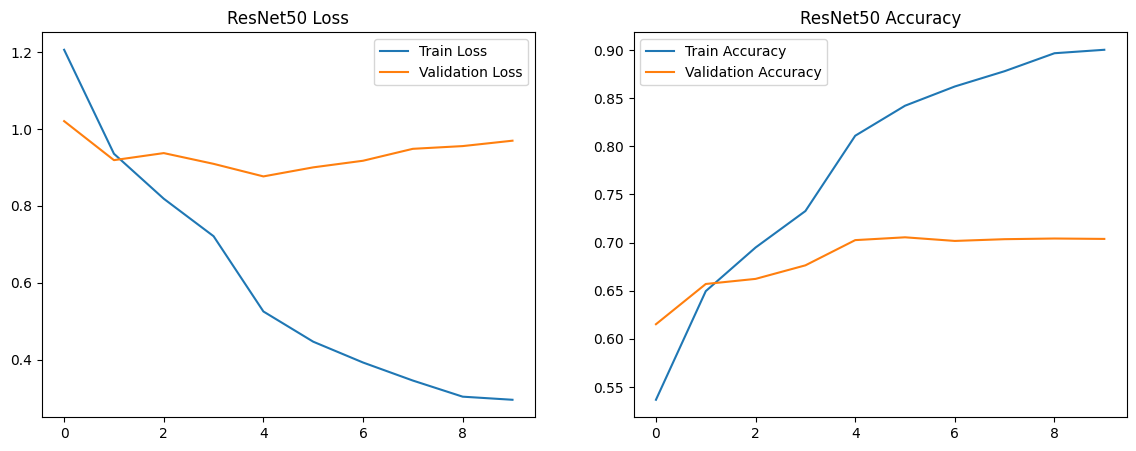

In [8]:
# BLOK 7: Eğitim Grafikleri
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('ResNet50 Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('ResNet50 Accuracy')
plt.legend()

plt.savefig('resnet50_temel_grafikler.png')
plt.show()


Gerçek Etiket: disgust
Tahmin Edilen: disgust (Güven: %73.2)
🎬 ÖNERİLEN FİLM
İsim : Schindler's List
Puan : 8.9 ⭐
Tür  : Biography, Drama, History
Yıl  : 1993


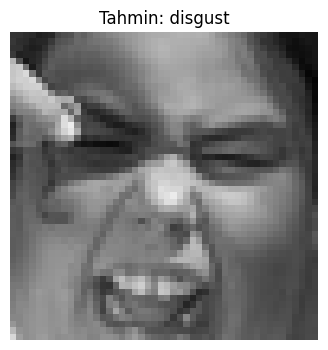

In [ ]:

emotion_genre_mapping = {
    'happy': ['Comedy', 'Musical', 'Animation', 'Family'],
    'sad': ['Drama', 'Romance', 'Biography'],
    'angry': ['Action', 'War', 'Crime', 'Western'],
    'fear': ['Horror', 'Thriller', 'Mystery'],
    'surprise': ['Sci-Fi', 'Fantasy', 'Adventure'],
    'disgust': ['History', 'Horror'],
    'neutral': ['Documentary', 'Biography', 'Drama']
}


def recommend_movie(predicted_emotion, csv_path='imdb_top_1000.csv'):
    
    if not os.path.exists(csv_path):
        return f"HATA: '{csv_path}' dosyası bulunamadı. Lütfen dosyayı Colab'e yükleyin."

    key = predicted_emotion.lower()

    try:
        df = pd.read_csv(csv_path)

        
        df.columns = [c.strip() for c in df.columns]

        genres = emotion_genre_mapping.get(key, [])
        if not genres:
            return "Bu duygu için tanımlı film türü yok."

        
        filtered = df[df['Genre'].fillna('').apply(lambda x: any(g in x for g in genres))]

        if filtered.empty:
            return "Kriterlere uygun film bulunamadı."

        
        return filtered.sort_values(by='IMDB_Rating', ascending=False).iloc[0]

    except Exception as e:
        return f"CSV Okuma Hatası: {str(e)}"


def test_single_image():
    model.eval()

    
    rand_cls = np.random.choice(class_names)
    fpath = os.path.join(test_dir, rand_cls)

    if not os.path.exists(fpath):
        print(f"Hata: {fpath} klasörü yok.")
        return

    img_name = np.random.choice(os.listdir(fpath))
    full_path = os.path.join(fpath, img_name)

    
    img = Image.open(full_path).convert('RGB')
    input_t = data_transforms['test'](img).unsqueeze(0).to(device)

    
    with torch.no_grad():
        out = model(input_t)
        prob = torch.nn.functional.softmax(out, dim=1)[0]
        conf, idx = torch.max(prob, 0)

    pred = class_names[idx]

    print("\n" + "="*30)
    print(f"Gerçek Etiket: {rand_cls}")
    print(f"Tahmin Edilen: {pred} (Güven: %{conf.item()*100:.1f})")
    print("="*30)

    
    movie = recommend_movie(pred)

    
    if isinstance(movie, str):
        print(f"⚠️ UYARI: Film önerilemedi -> {movie}")
    else:
        print(f"🎬 ÖNERİLEN FİLM")
        print(f"İsim : {movie['Series_Title']}")
        print(f"Puan : {movie['IMDB_Rating']} ⭐")
        print(f"Tür  : {movie['Genre']}")
        print(f"Yıl  : {movie['Released_Year']}")

    
    plt.figure(figsize=(4,4))
    plt.imshow(img)
    plt.title(f"Tahmin: {pred}")
    plt.axis('off')
    plt.show()


test_single_image()

Detaylı metrikler hesaplanıyor...


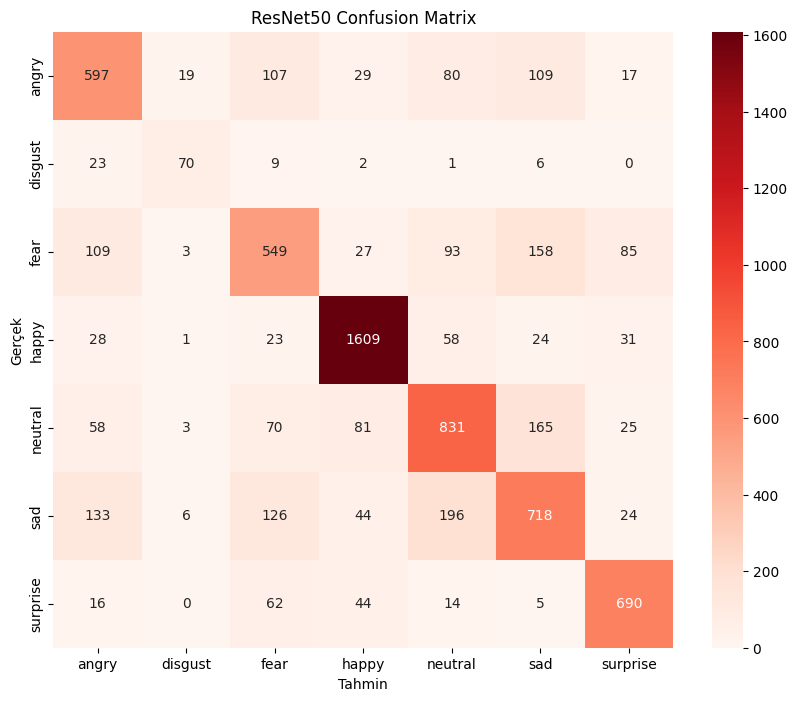


SINIF BAZLI PERFORMANS RAPORU
              precision    recall  f1-score      support
angry          0.619295  0.623173  0.621228   958.000000
disgust        0.686275  0.630631  0.657277   111.000000
fear           0.580338  0.536133  0.557360  1024.000000
happy          0.876362  0.906990  0.891413  1774.000000
neutral        0.652789  0.673966  0.663208  1233.000000
sad            0.605907  0.575782  0.590461  1247.000000
surprise       0.791284  0.830325  0.810335   831.000000
accuracy       0.705489  0.705489  0.705489     0.705489
macro avg      0.687464  0.682428  0.684469  7178.000000
weighted avg   0.701645  0.705489  0.703208  7178.000000


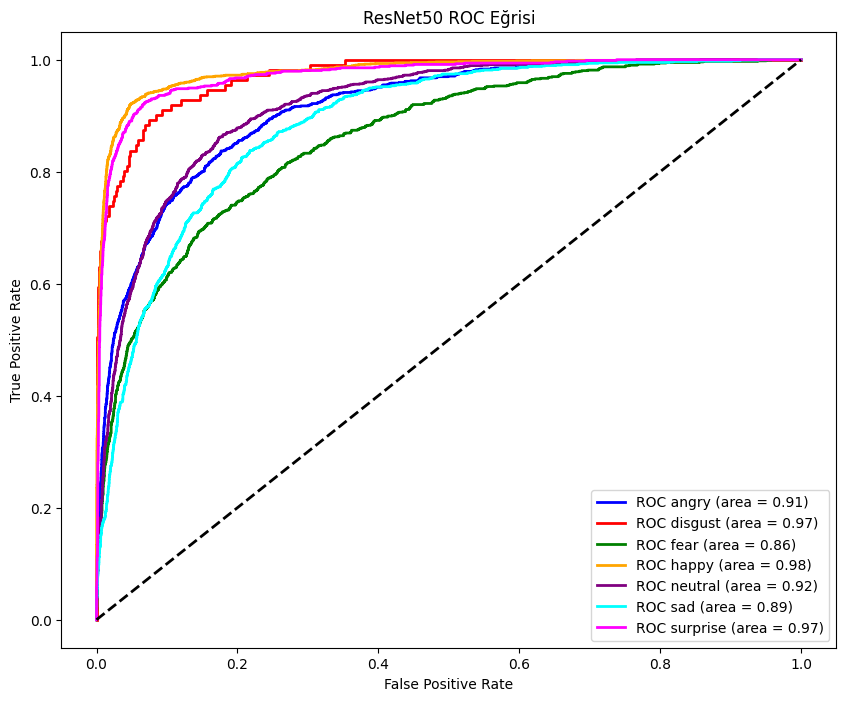

In [12]:
# BLOK 9: Detaylı Analiz (Confusion Matrix, ROC, Tablo)
def evaluate_comprehensive(model, dataloader, class_names):
    model.eval()
    y_true, y_pred, y_score = [], [], []

    print("Detaylı metrikler hesaplanıyor...")
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            probs = torch.nn.functional.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_score.extend(probs.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_score = np.array(y_score)

    # 1. Confusion Matrix (Karmaşıklık Matrisi)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    # ResNet50 için Kırmızı tonları kullanalım
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=class_names, yticklabels=class_names)
    plt.title('ResNet50 Confusion Matrix')
    plt.ylabel('Gerçek')
    plt.xlabel('Tahmin')
    plt.savefig('resnet50_confusion_matrix.png')
    plt.show()

    # 2. Sınıf Bazlı Performans Raporu
    print("\n" + "="*40)
    print("SINIF BAZLI PERFORMANS RAPORU")
    print("="*40)
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    print(df_report)
    df_report.to_csv('resnet50_detailed_metrics.csv')

    # 3. ROC Eğrisi ve AUC
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    fpr, tpr, roc_auc = dict(), dict(), dict()

    plt.figure(figsize=(10, 8))
    colors = cycle(['blue', 'red', 'green', 'orange', 'purple', 'cyan', 'magenta'])

    for i, color in zip(range(len(class_names)), colors):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label='ROC {0} (area = {1:0.2f})'.format(class_names[i], roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.title('ResNet50 ROC Eğrisi')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc="lower right")
    plt.savefig('resnet50_roc_curve.png')
    plt.show()

evaluate_comprehensive(model, dataloaders['test'], class_names)